# Structural SVM and Ranking SVM

## Learning Objectives

1. **Motivate** structured prediction: outputs are complex objects (sequences, trees, rankings)
2. **Define** the structured prediction model: $h(\mathbf{x}) = \arg\max_{\mathbf{y}\in\mathcal{Y}} \mathbf{w}^\top \Phi(\mathbf{x}, \mathbf{y})$
3. **State** the structural SVM constraints and derive the cutting-plane algorithm
4. **Apply** Struct-SVM to ranking: Ranking SVM with average precision loss
5. **Implement** a simple Struct-SVM for sequence labelling


## Problem Statement

### Structured Prediction

In structured prediction, the output space $\mathcal{Y}$ is complex (e.g., a sequence of labels, a parse tree, a ranking of documents). We learn a **scoring function** $f(\mathbf{x}, \mathbf{y}) = \mathbf{w}^\top \Phi(\mathbf{x}, \mathbf{y})$ where $\Phi(\mathbf{x}, \mathbf{y})$ is a joint feature vector. Prediction:
$$h(\mathbf{x}) = \arg\max_{\mathbf{y} \in \mathcal{Y}} \mathbf{w}^\top \Phi(\mathbf{x}, \mathbf{y})$$

### Structural SVM (Hard Margin)

Require that the true label $y_i$ scores higher than any other label $\mathbf{y}$ by at least $\Delta(y_i, \mathbf{y})$ (a task-specific loss):
$$\mathbf{w}^\top \Phi(\mathbf{x}_i, y_i) \geq \mathbf{w}^\top \Phi(\mathbf{x}_i, \mathbf{y}) + \Delta(y_i, \mathbf{y}) \quad \forall i, \mathbf{y} \in \mathcal{Y}$$

### Soft-Margin Structural SVM

With slack:
$$\min_{\mathbf{w}, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + \frac{C}{n}\sum_i \xi_i$$
$$\text{s.t. } \mathbf{w}^\top[\Phi(\mathbf{x}_i, y_i) - \Phi(\mathbf{x}_i, \mathbf{y})] \geq \Delta(y_i, \mathbf{y}) - \xi_i \quad \forall i, \mathbf{y}$$

At optimum: $\xi_i = \max_{\mathbf{y}} [\Delta(y_i, \mathbf{y}) + \mathbf{w}^\top\Phi(\mathbf{x}_i, \mathbf{y})] - \mathbf{w}^\top\Phi(\mathbf{x}_i, y_i)$

This is the **loss-augmented inference** problem.

### Ranking SVM

For document retrieval, the label $\mathbf{y}$ is a ranking of documents. The loss is $\Delta(y, y') = 1 - \text{AvgPrec}(y')$. The joint feature map:
$$\Psi(y', \mathbf{x}) = \sum_{i \neq j} y'_{ij} (\phi(\mathbf{x}_i) - \phi(\mathbf{x}_j))$$
where $y'_{ij} = 1$ if document $i$ is ranked above $j$.


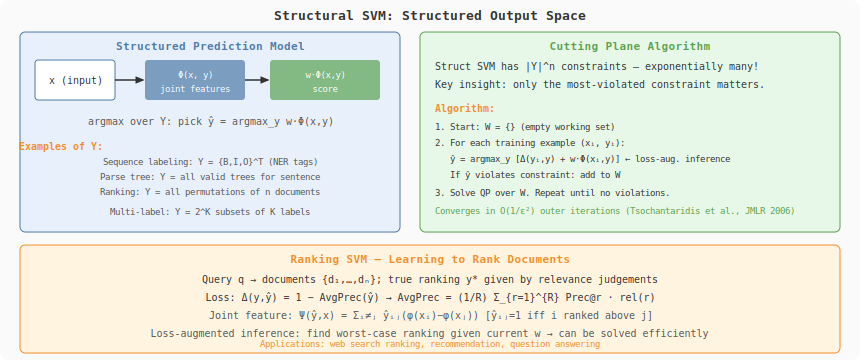

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="360" font-family="monospace" font-size="11">
  <rect width="860" height="360" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Structural SVM: Structured Output Space</text>

  <!-- Left: structured prediction overview -->
  <rect x="20" y="32" width="380" height="200" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="210" y="50" text-anchor="middle" fill="#4e79a7" font-weight="bold">Structured Prediction Model</text>

  <!-- Input -->
  <rect x="35" y="60" width="80" height="40" rx="3" fill="#fff" stroke="#4e79a7"/>
  <text x="75" y="84" text-anchor="middle" fill="#333" font-size="10">x (input)</text>

  <!-- Joint feature map -->
  <rect x="145" y="60" width="100" height="40" rx="3" fill="#4e79a7" opacity="0.7"/>
  <text x="195" y="78" text-anchor="middle" fill="#fff" font-size="9">Φ(x, y)</text>
  <text x="195" y="92" text-anchor="middle" fill="#fff" font-size="9">joint features</text>

  <!-- Score -->
  <rect x="270" y="60" width="110" height="40" rx="3" fill="#59a14f" opacity="0.7"/>
  <text x="325" y="78" text-anchor="middle" fill="#fff" font-size="9">w·Φ(x,y)</text>
  <text x="325" y="92" text-anchor="middle" fill="#fff" font-size="9">score</text>

  <!-- Arrows -->
  <line x1="115" y1="80" x2="143" y2="80" stroke="#333" stroke-width="1.5" marker-end="url(#a1)"/>
  <line x1="245" y1="80" x2="268" y2="80" stroke="#333" stroke-width="1.5" marker-end="url(#a1)"/>
  <defs><marker id="a1" markerWidth="6" markerHeight="5" refX="5" refY="2.5" orient="auto"><polygon points="0 0,6 2.5,0 5" fill="#333"/></marker></defs>

  <!-- Output space (enum possible y) -->
  <text x="210" y="125" text-anchor="middle" fill="#555" font-size="10">argmax over Y: pick ŷ = argmax_y w·Φ(x,y)</text>

  <!-- Examples of Y -->
  <text x="60" y="150" text-anchor="middle" fill="#f28e2b" font-size="10" font-weight="bold">Examples of Y:</text>
  <text x="210" y="165" text-anchor="middle" fill="#555" font-size="9">Sequence labeling: Y = {B,I,O}^T  (NER tags)</text>
  <text x="210" y="180" text-anchor="middle" fill="#555" font-size="9">Parse tree: Y = all valid trees for sentence</text>
  <text x="210" y="195" text-anchor="middle" fill="#555" font-size="9">Ranking: Y = all permutations of n documents</text>
  <text x="210" y="215" text-anchor="middle" fill="#555" font-size="9">Multi-label: Y = 2^K subsets of K labels</text>

  <!-- Right: Cutting plane -->
  <rect x="420" y="32" width="420" height="200" rx="5" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="630" y="50" text-anchor="middle" fill="#59a14f" font-weight="bold">Cutting Plane Algorithm</text>
  <text x="435" y="70" fill="#333" font-size="10">Struct SVM has |Y|^n constraints — exponentially many!</text>
  <text x="435" y="88" fill="#333" font-size="10">Key insight: only the most-violated constraint matters.</text>

  <text x="435" y="112" fill="#f28e2b" font-size="10" font-weight="bold">Algorithm:</text>
  <text x="435" y="130" fill="#333" font-size="9">1. Start: W = {}  (empty working set)</text>
  <text x="435" y="146" fill="#333" font-size="9">2. For each training example (xᵢ, yᵢ):</text>
  <text x="450" y="162" fill="#333" font-size="9">   ŷ = argmax_y [Δ(yᵢ,y) + w·Φ(xᵢ,y)]  ← loss-aug. inference</text>
  <text x="450" y="178" fill="#333" font-size="9">   If ŷ violates constraint: add to W</text>
  <text x="435" y="196" fill="#333" font-size="9">3. Solve QP over W. Repeat until no violations.</text>
  <text x="435" y="214" fill="#59a14f" font-size="9">Converges in O(1/ε²) outer iterations (Tsochantaridis et al., JMLR 2006)</text>

  <!-- Ranking SVM -->
  <rect x="20" y="245" width="820" height="108" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="430" y="263" text-anchor="middle" fill="#f28e2b" font-weight="bold">Ranking SVM — Learning to Rank Documents</text>
  <text x="430" y="283" text-anchor="middle" fill="#333" font-size="10">Query q → documents {d₁,…,dₙ}; true ranking y* given by relevance judgements</text>
  <text x="430" y="301" text-anchor="middle" fill="#333" font-size="10">Loss: Δ(y,ŷ) = 1 − AvgPrec(ŷ)   →   AvgPrec = (1/R) Σ_{r=1}^{R} Prec@r · rel(r)</text>
  <text x="430" y="319" text-anchor="middle" fill="#555" font-size="10">Joint feature: Ψ(ŷ,x) = Σᵢ≠ⱼ ŷᵢⱼ(φ(xᵢ)−φ(xⱼ))  [ŷᵢⱼ=1 iff i ranked above j]</text>
  <text x="430" y="337" text-anchor="middle" fill="#555" font-size="10">Loss-augmented inference: find worst-case ranking given current w → can be solved efficiently</text>
  <text x="430" y="347" text-anchor="middle" fill="#f28e2b" font-size="9">Applications: web search ranking, recommendation, question answering</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Cutting Plane Convergence

The full Struct-SVM QP has $O(n|\mathcal{Y}|)$ constraints. The cutting-plane algorithm maintains a **working set** $\mathcal{W}$ of active constraints. At each outer iteration, it finds the most violated constraint (loss-augmented inference) and adds it to $\mathcal{W}$.

**Theorem** (Tsochantaridis et al., 2006): After $O(1/\varepsilon^2)$ outer iterations, the solution satisfies $f(\mathbf{w}) \leq f(\mathbf{w}^*) + \varepsilon$.

### Loss-Augmented Inference

The key computational bottleneck is finding:
$$\hat{\mathbf{y}}_i = \arg\max_{\mathbf{y} \in \mathcal{Y}} \left[\Delta(y_i, \mathbf{y}) + \mathbf{w}^\top \Phi(\mathbf{x}_i, \mathbf{y})\right]$$

For many structured problems (sequences, trees), this can be solved efficiently:
- **Sequence labelling**: Viterbi + modified transition costs from the loss
- **Parse trees**: CYK algorithm with loss-modified scores
- **Rankings**: sorting with modified scores

### Struct-SVM vs. CRF

| | Structural SVM | CRF |
|---|---|---|
| Objective | Margin loss | Log-likelihood |
| Training | Cutting plane / SSG | L-BFGS |
| Sparsity | Sparse dual solution | Dense |
| Loss function | Arbitrary task loss | Only log-loss |


In [2]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


class StructSVM:
    """
    Structural SVM for sequence labelling (small vocabulary, short sequences).
    Uses subgradient descent for simplicity (not full cutting plane).

    Feature map: Φ(x, y) = [emission features, transition features]
    Emission: one-hot(y_t) ⊗ x_t    (which label fires on which input)
    Transition: one-hot(y_t, y_{t+1})  (bigram label pairs)
    """

    def __init__(self, n_labels, n_features, C=1.0, lr=0.01, max_iter=500, seed=0):
        rng = np.random.default_rng(seed)
        self.K = n_labels
        self.D = n_features
        self.C = C
        self.lr = lr
        self.max_iter = max_iter
        # w = [emission: K*D, transition: K*K]
        self.w = rng.normal(0, 0.01, n_labels * n_features + n_labels * n_labels)

    def _score(self, x_seq, y_seq):
        """Score w · Φ(x, y) for a sequence."""
        K, D = self.K, self.D
        T = len(x_seq)
        s = 0.0
        for t in range(T):
            s += self.w[y_seq[t]*D : y_seq[t]*D+D] @ x_seq[t]
            if t < T-1:
                s += self.w[K*D + y_seq[t]*K + y_seq[t+1]]
        return s

    def _viterbi(self, x_seq):
        """Viterbi decoding: argmax_y w·Φ(x,y)."""
        K, D = self.K, self.D
        T = len(x_seq)
        dp = np.full((T, K), -np.inf)
        bp = np.zeros((T, K), dtype=int)

        for k in range(K):
            dp[0, k] = self.w[k*D:k*D+D] @ x_seq[0]

        for t in range(1, T):
            trans = self.w[K*D:K*D+K*K].reshape(K, K)
            for k in range(K):
                emit = self.w[k*D:k*D+D] @ x_seq[t]
                scores = dp[t-1] + trans[:, k]
                bp[t, k] = scores.argmax()
                dp[t, k] = scores.max() + emit

        y_pred = [int(dp[-1].argmax())]
        for t in range(T-1, 0, -1):
            y_pred.append(int(bp[t, y_pred[-1]]))
        return list(reversed(y_pred))

    def _loss_augmented_viterbi(self, x_seq, y_true):
        """Loss-augmented Viterbi: argmax_y [Δ(y_true, y) + w·Φ(x,y)]."""
        K, D = self.K, self.D
        T = len(x_seq)
        dp = np.full((T, K), -np.inf)
        bp = np.zeros((T, K), dtype=int)

        for k in range(K):
            hamming_0 = 1.0 if k != y_true[0] else 0.0
            dp[0, k] = self.w[k*D:k*D+D] @ x_seq[0] + hamming_0

        trans = self.w[K*D:K*D+K*K].reshape(K, K)
        for t in range(1, T):
            for k in range(K):
                emit    = self.w[k*D:k*D+D] @ x_seq[t]
                hamming = 1.0 if k != y_true[t] else 0.0
                scores  = dp[t-1] + trans[:, k]
                bp[t, k] = scores.argmax()
                dp[t, k] = scores.max() + emit + hamming

        y_pred = [int(dp[-1].argmax())]
        for t in range(T-1, 0, -1):
            y_pred.append(int(bp[t, y_pred[-1]]))
        return list(reversed(y_pred))

    def _phi_diff(self, x_seq, y_true, y_pred):
        """Φ(x, y_true) − Φ(x, y_pred)."""
        K, D = self.K, self.D
        diff = np.zeros_like(self.w)
        T = len(x_seq)
        for t in range(T):
            diff[y_true[t]*D:y_true[t]*D+D] += x_seq[t]
            diff[y_pred[t]*D:y_pred[t]*D+D] -= x_seq[t]
            if t < T-1:
                diff[K*D + y_true[t]*K + y_true[t+1]] += 1
                diff[K*D + y_pred[t]*K + y_pred[t+1]] -= 1
        return diff

    def fit(self, data):
        """data: list of (x_seq, y_seq) pairs."""
        n = len(data)
        lam = 1.0 / (n * self.C)
        losses = []
        for t in range(1, self.max_iter+1):
            eta = self.lr / np.sqrt(t)
            rng = np.random.default_rng(t)
            x_seq, y_true = data[rng.integers(n)]
            y_pred = self._loss_augmented_viterbi(x_seq, y_true)
            loss = sum(yt != yp for yt, yp in zip(y_true, y_pred))
            losses.append(loss)
            if loss == 0:
                self.w *= (1 - eta * lam)
                continue
            diff = self._phi_diff(x_seq, y_true, y_pred)
            self.w = (1 - eta * lam) * self.w + eta * diff
        return self, losses

    def predict(self, x_seq):
        return self._viterbi(x_seq)


# ── Synthetic sequence labelling dataset ─────────────────────────────────────
rng = np.random.default_rng(42)
K = 3   # labels: 0, 1, 2
D = 4   # features per token
n_train = 200
T = 5   # sequence length

class_means = rng.standard_normal((K, D))

data = []
for _ in range(n_train):
    y_seq = list(rng.integers(K, size=T))
    x_seq = np.array([class_means[y] + rng.normal(0, 0.5, D) for y in y_seq])
    data.append((x_seq, y_seq))

model, losses = StructSVM(n_labels=K, n_features=D, C=1.0, lr=0.1, max_iter=2000).fit(data)

correct = sum(
    sum(p == t for p, t in zip(model.predict(x), y))
    for x, y in data
)
total = n_train * T
print(f"Token-level accuracy: {correct/total:.2%}")

seq_acc = sum(model.predict(x) == y for x, y in data)
print(f"Sequence-level accuracy: {seq_acc}/{n_train}")

# ── Learning curve ────────────────────────────────────────────────────────────
window = 50
smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(smoothed, color='#4e79a7', linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel(f"Hamming loss (moving avg {window})")
ax.set_title("Struct-SVM Subgradient: Training Loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("struct_svm_training.png", dpi=110)
plt.show()
print("Saved struct_svm_training.png")


Token-level accuracy: 75.60%
Sequence-level accuracy: 48/200
Saved struct_svm_training.png


/tmp/ipykernel_305850/3989996591.py:161: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
